<a href="https://colab.research.google.com/github/muskanborgohain2102-sketch/Repository-4-Helical-Gear-Design/blob/main/Helical%20Gear%20Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---Gear Geometry ---
Pitch Diameter = 82.82 mm
Base Diameter = 77.83 mm
Addendum = 4.00 mm
Dedendum = 5.00 mm
Whole Depth = 9.00 mm

---Gear Forces ---
Tangential Force          : 72.44 N
Radial Force              : 27.30 N
Axial Force               : 19.41 N
Resultant Force           : 79.81 N

---Strength Analysis ---
Bending Stress            : 174.94 MPa
Factor of Safety= 1.71


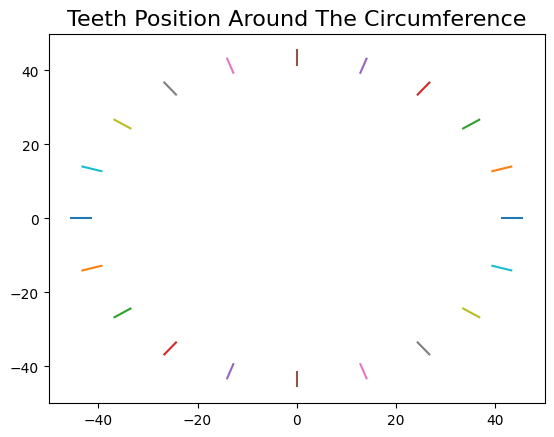

In [19]:
import math
import matplotlib.pyplot as plt

class HelicalGearGeometry:

    def __init__(self,
                 module,
                 number_of_teeth,
                 helix_angle,
                 pressure_angle):

        self.module = module
        self.z = number_of_teeth

        self.helix_angle = math.radians(helix_angle)
        self.pressure_angle = math.radians(pressure_angle)

        self.calculate_geometry()

    def calculate_geometry(self):

        self.transverse_module = (
            self.module /
            math.cos(self.helix_angle)
        )

        self.pitch_diameter = (
            self.z *
            self.transverse_module
        )

        self.base_diameter = (
            self.pitch_diameter *
            math.cos(self.pressure_angle)
        )

        self.addendum = self.module

        self.dedendum = (
            1.25 *
            self.module
        )

        self.whole_depth = (
            self.addendum +
            self.dedendum
        )

        self.outside_diameter = (
            self.pitch_diameter +
            2 * self.addendum
        )

        self.root_diameter = (
            self.pitch_diameter -
            2 * self.dedendum
        )

        self.clearance = (
            0.25 *
            self.module
        )

        self.transverse_pressure_angle = math.atan(
            math.tan(self.pressure_angle) /
            math.cos(self.helix_angle)
        )

        self.transverse_pitch = (
            math.pi *
            self.transverse_module
        )

        self.axial_pitch = (
            self.transverse_pitch /
            math.cos(self.helix_angle)
        )
class GearLoading:

    def __init__(self,
                 geometry,
                 torque,
                 speed):

        self.geometry = geometry

        self.torque = torque
        self.speed = speed

        self.calculate_loads()

    def calculate_loads(self):

        d = self.geometry.pitch_diameter

        self.tangential_force = (
            2 * self.torque /
            d
        )

        self.radial_force = (
            self.tangential_force *
            math.tan(
                self.geometry.transverse_pressure_angle
            )
        )

        self.axial_force = (
            self.tangential_force *
            math.tan(
                self.geometry.helix_angle
            )
        )

        self.resultant_force = math.sqrt(
            self.tangential_force**2 +
            self.radial_force**2 +
            self.axial_force**2
        )

class GearStrength:

    def __init__(self,
                 geometry,
                 loading,
                 material_strength,
                 face_width):

        self.geometry = geometry
        self.loading = loading

        self.material_strength = material_strength
        self.face_width = face_width

    def calculate_bending_stress(self):

        Ft = self.loading.tangential_force

        return (
            Ft *
            self.face_width /
            (
                self.geometry.module *
                self.geometry.transverse_module
            )
        )

    def calculate_factor_of_safety(self):

        stress = (
            self.calculate_bending_stress()
        )

        return (
            self.material_strength /
            stress
        )

# Geometry

gear = HelicalGearGeometry(
    module=4,
    number_of_teeth=20,
    helix_angle=15,
    pressure_angle=20
)

# Loading

load_case = GearLoading(
    geometry=gear,
    torque=3000,
    speed=1500
)

# Strength

strength = GearStrength(
    geometry=gear,
    loading=load_case,
    material_strength=300,
    face_width=40
)

print("\n---Gear Geometry ---")

print(f"Pitch Diameter = {gear.pitch_diameter:.2f} mm")
print(f"Base Diameter = {gear.base_diameter:.2f} mm")
print(f"Addendum = {gear.addendum:.2f} mm")
print(f"Dedendum = {gear.dedendum:.2f} mm")
print(f"Whole Depth = {gear.whole_depth:.2f} mm")

print("\n---Gear Forces ---")

print(f"{'Tangential Force':<25} : {load_case.tangential_force:.2f} N")
print(f"{'Radial Force':<25} : {load_case.radial_force:.2f} N")
print(f"{'Axial Force':<25} : {load_case.axial_force:.2f} N")
print(f"{'Resultant Force':<25} : {load_case.resultant_force:.2f} N")

print("\n---Strength Analysis ---")

print(
    f"{'Bending Stress':<25} : {strength.calculate_bending_stress():.2f} MPa"
)
print(
    f"Factor of Safety= "
    f"{strength.calculate_factor_of_safety():.2f}"
)
for i in range(gear.z):

    angle = 2 * math.pi * i / gear.z

    x1 = (gear.pitch_diameter/2) * math.cos(angle)
    y1 = (gear.pitch_diameter/2) * math.sin(angle)

    x2 = (gear.outside_diameter/2) * math.cos(angle)
    y2 = (gear.outside_diameter/2) * math.sin(angle)

    plt.plot([x1, x2], [y1, y2])
    plt.title("Teeth Position Around The Circumference", fontsize=16)
